# Problem

**State Space**

The state space consists of two discrete states:
$$
\mathcal{X} = \{0, 1\}.
$$

These can be interpreted as two different situations or system configurations, for instance, a “low-performance” state (0) and a “high-performance” state (1).

 **Action Space**

The action space consists of two discrete actions:
$$
\mathcal{A} = \{0, 1\}.
$$

These actions can be thought of as two control options available to the agent — for example:

* **Action 0**: Conservative or “stay” action (keeps the system near state 0)
* **Action 1**: Aggressive or “move” action (pushes the system toward state 1)

**Reward Function**

The reward is explicitly given by:
$$
r(x,a) = x + a.
$$

This means:
* Rewards increase with higher actions.
* Being in the “high” state (1) also provides additional reward.

**Transition Function**

Deterministic transition dynamics:

* If the agent takes **action 0**, it always transitions to state 0.
* If the agent takes **action 1**, it always transitions to state 1.

In tabular form:

| Current (x,a) | P(x′=0) | P(x′=1) |
| ------------- | ------- | ------- |
| (0,0)         | 1.0     | 0.0     |
| (0,1)         | 0.0     | 1.0     |
| (1,0)         | 1.0     | 0.0     |
| (1,1)         | 0.0     | 1.0     |

In [55]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def tensor64(data):
    return torch.as_tensor(data, dtype=torch.float64)

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"
# Add project root to the Python path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods import TabularPolicyFeatures, LinearPolicyFOGAS, VBetaLogitSolver, VBetaObjectivePolicySolver, VBetaSolver, FOGASHyperOptimizer, FOGASEvaluator, PolicySolver, FOGASSolverBetaVectorized

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Tabular Features

## Testing

In [51]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)
gamma_2d = 0.99
x_0 = 0 # fixed initial state

def phi(state, action):
    vec = torch.zeros(4, dtype=torch.float64)
    vec[int(state) * 2 + int(action)] = 1.0
    return vec

omega = tensor64([0, 1.0, 1.0, 2.0])

psi = {
    0: tensor64([1.0, 0, 1.0, 0]),
    1: tensor64([0, 1.0, 0, 1.0])
}


mdp = PolicySolver(states=states_2d, actions=actions_2d, phi=phi, omega=omega, gamma=gamma_2d, x0=x_0, psi=psi)

## Beta

In [34]:
solver_e = VBetaSolver(mdp=mdp, print_params=True, csv_path=str(DATASETS_DIR / "dumb_problem.csv"), seed=SEED, device=DEVICE)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"))


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      46.27564263195184
T (iterations):                47

FOGAS Hyperparameters
---------------------
alpha:                        0.000859
rho:                            1945.036816
eta:                            0.000070
D_theta:                    20.000000
beta (ridge):             0.005319
D_pi (derived):           0.807192




In [35]:
solver_e.run(alpha=1e-2, eta=1e-2, rho=0.5, tqdm_print=True, T=800)
evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()

FOGAS: 100%|██████████| 800/800 [00:00<00:00, 3132.47it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  153.661118 | Δ = -4.533888e+01
State 1: V*(x) =  200.000000 | V^π(x) =  154.270010 | Δ = -4.572999e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  152.124506 | Δ = -4.488549e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  153.727309 | Δ = -4.527269e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  153.124506 | Δ = -4.488549e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  154.727309 | Δ = -4.527269e+01

Norm diagnostics:
||V^π - V*||_2 = 6.439601e+01
||Q^π - Q*||_2 = 9.015902e+01



========== FINAL REWARD COMPARISON ==========

J*(π*)   = 1.990000
J(π_FOGAS) = 1.536611
Gap (J* − J) = 4.533888e-01




In [36]:
evaluator_e.print_policy()

  State 0: π(a=0|s=0) = 0.04  π(a=1|s=0) = 0.96  --> best action: 1
  State 1: π(a=0|s=1) = 0.29  π(a=1|s=1) = 0.71  --> best action: 1



## Policy

### Objective-update

In [38]:
solver_e = VBetaObjectivePolicySolver(
    mdp=mdp,
    print_params=True,
    csv_path=str(DATASETS_DIR / "dumb_problem.csv"),
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    metric_callable=evaluator_e.get_metric("reward"),
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      46.27564263195184
T (iterations):                47

FOGAS Hyperparameters
---------------------
alpha:                        0.000859
rho:                            1945.036816
eta:                            0.000070
D_theta:                    20.000000
beta (ridge):             0.005319
D_pi (derived):           0.807192




In [47]:
solver_e.run(
    alpha=2e-2,
    eta=1e-2,
    rho=0.5,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=800,
)

[FOGAS objective-policy] Iter 1/800 total_loss=0.000000e+00 policy_loss=0.000000e+00 theta_norm=2.000000e+01 beta_norm=1.977551e-01 grad_norm=1.987439e+01 policy_grad_norm=0.000000e+00
[FOGAS objective-policy] Iter 51/800 total_loss=-1.388739e-01 policy_loss=1.869506e-01 theta_norm=2.000000e+01 beta_norm=9.451565e-01 grad_norm=3.088551e+01 policy_grad_norm=4.460103e+00
[FOGAS objective-policy] Iter 101/800 total_loss=1.725808e-01 policy_loss=1.468487e+00 theta_norm=2.000000e+01 beta_norm=1.625663e+00 grad_norm=2.995224e+01 policy_grad_norm=8.111563e+00
[FOGAS objective-policy] Iter 151/800 total_loss=1.992248e-01 policy_loss=1.542718e+00 theta_norm=2.000000e+01 beta_norm=2.135684e+00 grad_norm=2.877579e+01 policy_grad_norm=1.091732e+01
[FOGAS objective-policy] Iter 201/800 total_loss=8.632893e-02 policy_loss=2.565131e-01 theta_norm=2.000000e+01 beta_norm=2.469006e+00 grad_norm=2.660515e+01 policy_grad_norm=1.316266e+01
[FOGAS objective-policy] Iter 251/800 total_loss=1.723400e-02 polic

tensor([[0.4106, 0.5894],
        [0.1414, 0.8586]])

In [48]:
diagnostics = solver_e.get_diagnostics()

evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  159.903583 | Δ = -3.909642e+01
State 1: V*(x) =  200.000000 | V^π(x) =  161.633935 | Δ = -3.836607e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  158.304547 | Δ = -3.870545e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  161.017595 | Δ = -3.798240e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  159.304547 | Δ = -3.870545e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  162.017595 | Δ = -3.798240e+01

Norm diagnostics:
||V^π - V*||_2 = 5.477668e+01
||Q^π - Q*||_2 = 7.669127e+01



========== FINAL REWARD COMPARISON ==========

J*(π*)   = 1.990000
J(π_FOGAS) = 1.599036
Gap (J* − J) = 3.909642e-01




### Tabular policy MA

In [52]:
solver_e = VBetaLogitSolver(
    mdp=mdp,
    print_params=True,
    csv_path=str(DATASETS_DIR / "dumb_problem.csv"),
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    metric_callable=evaluator_e.get_metric("reward"),
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      46.27564263195184
T (iterations):                47

FOGAS Hyperparameters
---------------------
alpha:                        0.000859
rho:                            1945.036816
eta:                            0.000070
D_theta:                    20.000000
beta (ridge):             0.005319
D_pi (derived):           0.807192




In [53]:
solver_e.run(
    alpha=2e-2,
    eta=1e-2,
    rho=0.5,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=800,
)

[FOGAS logit-policy] Iter 1/800 total_loss=-1.414214e-01 policy_loss=-1.414214e-01 theta_norm=2.000000e+01 beta_norm=1.977551e-01 grad_norm=1.987439e+01 policy_grad_norm=2.000000e-01 psi_norm=4.000000e-03 state_weight_update=normal state_weight_min=0.000000e+00 state_weight_max=1.000000e-02 policy_state_weight_min=0.000000e+00 policy_state_weight_max=1.000000e-02
[FOGAS logit-policy] Iter 51/800 total_loss=-2.127973e-01 policy_loss=1.165640e-01 theta_norm=2.000000e+01 beta_norm=9.462582e-01 grad_norm=3.092325e+01 policy_grad_norm=4.550392e+00 psi_norm=6.493869e-01 state_weight_update=normal state_weight_min=2.229855e-01 state_weight_max=2.310640e-01 policy_state_weight_min=2.229855e-01 policy_state_weight_max=2.310640e-01
[FOGAS logit-policy] Iter 101/800 total_loss=1.165687e-01 policy_loss=1.424608e+00 theta_norm=2.000000e+01 beta_norm=1.627063e+00 grad_norm=2.998805e+01 policy_grad_norm=8.178690e+00 psi_norm=8.739364e-01 state_weight_update=normal state_weight_min=3.194754e-01 state_

tensor([[0.4088, 0.5912],
        [0.1413, 0.8587]])

In [54]:
evaluator_e.print_policy()

  State 0: π(a=0|s=0) = 0.41  π(a=1|s=0) = 0.59  --> best action: 1
  State 1: π(a=0|s=1) = 0.14  π(a=1|s=1) = 0.86  --> best action: 1



### Tabular SGD/Adam

In [57]:
policy_features = TabularPolicyFeatures(mdp.N, mdp.A)

solver_e = LinearPolicyFOGAS(
    mdp=mdp,
    csv_path=str(DATASETS_DIR / "dumb_problem.csv"),
    seed=SEED,
    device=DEVICE,
    policy_features=policy_features,
)


evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    metric_callable=evaluator_e.get_metric("reward"),
)

In [67]:
solver_e.run(
    alpha=4e-2,              # policy optimizer learning rate
    eta=1e-2,                # beta update learning rate
    rho=0.5,
    policy_optimizer="adam",  # or "adam"
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,
)

[FOGAS linear-policy] Iter 1/2000 total_loss=-1.414214e-01 policy_objective=-1.414214e-01 theta_norm=2.000000e+01 beta_norm=1.977551e-01 grad_norm=1.987439e+01 policy_grad_norm=0.000000e+00 psi_norm=0.000000e+00 policy_optimizer=adam state_weight_update=normal state_weight_min=0.000000e+00 state_weight_max=1.000000e-02 policy_state_weight_min=0.000000e+00 policy_state_weight_max=1.000000e-02
[FOGAS linear-policy] Iter 51/2000 total_loss=-4.176672e-01 policy_objective=6.347531e-01 theta_norm=2.000000e+01 beta_norm=9.459577e-01 grad_norm=2.915589e+01 policy_grad_norm=3.719026e-01 psi_norm=1.200618e+00 policy_optimizer=adam state_weight_update=normal state_weight_min=1.690579e-01 state_weight_max=2.379043e-01 policy_state_weight_min=1.690579e-01 policy_state_weight_max=2.379043e-01
[FOGAS linear-policy] Iter 101/2000 total_loss=9.797250e-02 policy_objective=2.705711e+00 theta_norm=2.000000e+01 beta_norm=1.683429e+00 grad_norm=2.924469e+01 policy_grad_norm=6.649911e-01 psi_norm=1.234636e+0

tensor([[0.3842, 0.6158],
        [0.2293, 0.7707]])

In [65]:
evaluator_e.print_policy()

  State 0: π(a=0|s=0) = 0.40  π(a=1|s=0) = 0.60  --> best action: 1
  State 1: π(a=0|s=1) = 0.22  π(a=1|s=1) = 0.78  --> best action: 1



# Funky Features

## Definition

**Feature Map**

The MDP follows the **Linear MDP assumption**, where both the reward and transition dynamics are linear in a known feature map $ \phi(x,a) $.

The feature representation is defined as:
$$
\phi(x,a) = 2 *
\begin{bmatrix}
1 \\
x \\
a
\end{bmatrix}
\in \mathbb{R}^3.
$$

**Reward Function**

The reward function is a linear combination of the feature vector:
$$
r(x,a) = \phi(x,a)^\top \omega,
$$
with the weight vector
$$
\omega = \frac{1}{2}
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}.
$$

**Transition Function**

The transition model is also linear in the features.
We define a collection of transition weight vectors $ \psi(x') $ such that
$$
p(x'|x,a) = \phi(x,a)^\top \psi(x').
$$

Specifically, the weights are:
$$
\psi(0) = \frac{1}{2}
\begin{bmatrix}
1 \\
0 \\
-1
\end{bmatrix}, \quad
\psi(1) = \frac{1}{2}
\begin{bmatrix}
0 \\
0 \\
1
\end{bmatrix}.
$$

## Testing

In [24]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)
gamma_2d = 0.99
x_0 = 0 # fixed initial state

def phi(state, action):
    return 2.0 * tensor64([1.0, float(state), float(action)])

omega = tensor64([0, 0.5, 0.5]) # reward depends on x and a

psi = {
    0: 0.5 * tensor64([1.0, 0.0, -1.0]),  # transition weights for next state 0
    1: 0.5 * tensor64([0.0, 0.0, 1.0])   # transition weights for next state 1
}

mdp = PolicySolver(states=states_2d, actions=actions_2d, phi=phi, omega=omega, gamma=gamma_2d, x0=x_0, psi=psi)


### Oracle

In [3]:
solver = FOGASOracleSolver(mdp=mdp, cov_matrix="identity", print_params=True, T=600, seed=SEED, device=DEVICE)
evaluator = FOGASEvaluator(solver)
optimizer = FOGASHyperOptimizer(solver=solver,metric_callable=evaluator.get_metric("reward"))



================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           10000000.0
Feature norm bound R:     3.4641
Num states N:             2
Num actions A:            2
Feature dim d:            3
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      55530771.1583422
T (iterations):                600   (overridden → 600)

FOGAS Hyperparameters
---------------------
alpha:                        0.000080
rho:                            5.335644
eta:                            0.000008
D_theta:                    17.320508
beta (ridge):             0.006667
D_pi (derived):           0.832555




Only when changing orders: first eta!! It is the most important one here.


=== FOGAS Hyperparameter Optimization ===
[Theory] metric = -0.7041
Order: ('eta', 'rho', 'alpha')

Optimizing eta
[After eta*] alpha=8.0113e-05, rho=1.0000e-02, eta=8.8077e-01 | metric = -1.0403

Optimizing rho
[After rho*] alpha=8.0113e-05, rho=1.0000e-03, eta=8.8077e-01 | metric = -1.0410

Optimizing alpha
[After alpha*] alpha=3.4658e-02, rho=1.0000e-03, eta=8.8077e-01 | metric = -1.9900


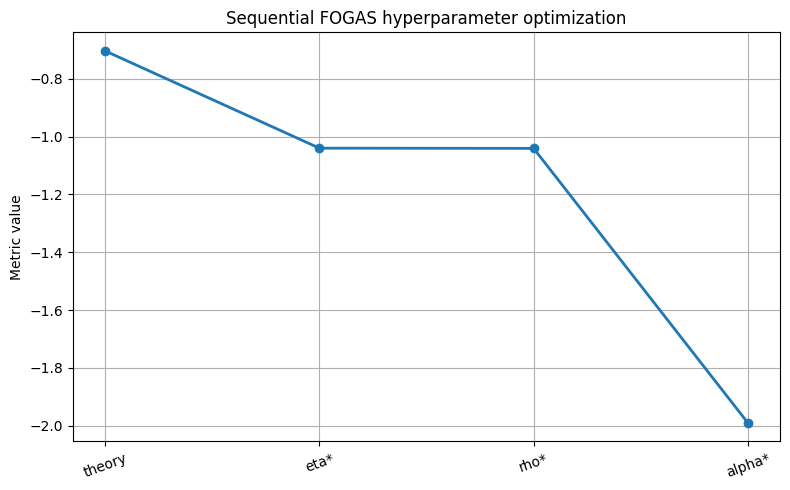

In [6]:
summary = optimizer.optimize_fogas_hyperparameters(
    search_method="random",
    coarse_points=20,
    print_main=True, 
    num_runs=2,
    order=("eta", "rho", "alpha")
)

alpha_star = summary["alpha"]
rho_star = summary["rho"]
eta_star = summary["eta"]

In [8]:
solver.run(alpha=alpha_star, eta=eta_star, rho=rho_star, tqdm_print=True)
evaluator.compare_value_functions()

FOGAS:   0%|          | 0/600 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 600/600 [00:00<00:00, 6593.49it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  199.000000 | Δ =  3.410605e-13
State 1: V*(x) =  200.000000 | V^π(x) =  200.000000 | Δ =  3.410605e-13

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  197.010000 | Δ =  3.410605e-13
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  199.000000 | Δ =  3.410605e-13
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  198.010000 | Δ =  3.410605e-13
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  200.000000 | Δ =  3.410605e-13

Norm diagnostics:
||V^π - V*||_2 = 4.823324e-13
||Q^π - Q*||_2 = 6.821210e-13




### Empirical

In [25]:
solver_e = FOGASSolverBetaVectorized(mdp=mdp, print_params=True, csv_path=str(DATASETS_DIR / "dumb_problem.csv"), seed=SEED, device=DEVICE)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"))



Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     3.4641
Num states N:             2
Num actions A:            2
Feature dim d:            3
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      555.3077115834219
T (iterations):                556

FOGAS Hyperparameters
---------------------
alpha:                        0.000083
rho:                            1680.895969
eta:                            0.000008
D_theta:                    17.320508
beta (ridge):             0.007194
D_pi (derived):           0.801446




Trying same optimal hyperparameters found for the oracle.

In [27]:
solver_e.run(alpha=1e-2, eta=4e-3, rho=0.5, tqdm_print=True, T=1000)
evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()
evaluator_e.print_policy()

FOGAS:  23%|██▎       | 231/1000 [00:00<00:00, 2302.08it/s]

FOGAS: 100%|██████████| 1000/1000 [00:00<00:00, 1963.53it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  174.943408 | Δ = -2.405659e+01
State 1: V*(x) =  200.000000 | V^π(x) =  175.943408 | Δ = -2.405659e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  173.193974 | Δ = -2.381603e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  175.183974 | Δ = -2.381603e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  174.193974 | Δ = -2.381603e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  176.183974 | Δ = -2.381603e+01

Norm diagnostics:
||V^π - V*||_2 = 3.402116e+01
||Q^π - Q*||_2 = 4.763205e+01



========== FINAL REWARD COMPARISON ==========

J*(π*)   = 1.990000
J(π_FOGAS) = 1.749434
Gap (J* − J) = 2.405659e-01


  State 0: π(a=0|s=0) = 0.12  π(a=1|s=0) = 0.88  --> best action: 1
  State 1: π(a=0|s=1) = 0.12  π(a=1|s=1) = 0.88  --> best action: 1

